# HI

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/bank.csv")

## Phase 1 — Understand & Validate the Data

In [ ]:
df.shape

(11162, 17)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [ ]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(col," : " ,df[col].unique())
    print("\n")

job  :  ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']


marital  :  ['married' 'single' 'divorced']


education  :  ['secondary' 'tertiary' 'primary' 'unknown']


default  :  ['no' 'yes']


housing  :  ['yes' 'no']


loan  :  ['no' 'yes']


contact  :  ['unknown' 'cellular' 'telephone']


month  :  ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


poutcome  :  ['unknown' 'other' 'failure' 'success']


deposit  :  ['yes' 'no']




## Phase 2 — Overall Campaign Performance

In [ ]:
summary = pd.Series({
    "Total Customers": len(df),
    "Subscribed": (df["deposit"] == "yes").sum(),
    "Not Subscribed": (df["deposit"] == "no").sum(),
    "Subscription Rate (%)": (df["deposit"] == "yes").mean() * 100
})
summary

,0
Total Customers,11162.000000
Subscribed,5289.000000
Not Subscribed,5873.000000
Subscription Rate (%),47.383981


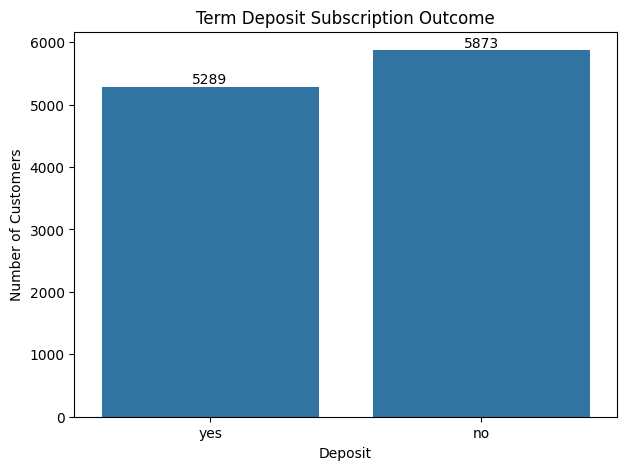

In [ ]:
plt.figure(figsize=(7,5))
ax=sns.countplot(data=df, x="deposit")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Term Deposit Subscription Outcome")
plt.xlabel("Deposit")
plt.ylabel("Number of Customers")
plt.show()

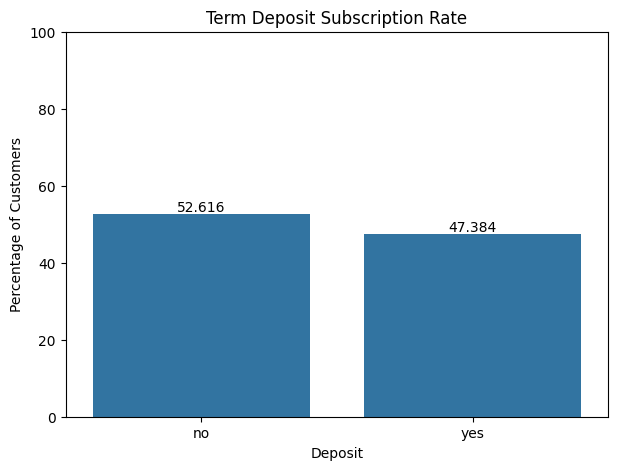

In [ ]:
deposit_rate = df["deposit"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))
ax=sns.barplot(x=deposit_rate.index, y=deposit_rate.values)
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Term Deposit Subscription Rate")
plt.xlabel("Deposit")
plt.ylabel("Percentage of Customers")
plt.ylim(0,100)
plt.show()

The campaign generated a 47.4% subscription rate, with 5,289 of 11,162 customers subscribing. The results are fairly balanced, with a slight majority of customers not subscribing. Campaign performance should be evaluated against the bank's target or historical benchmark to determine whether it was successful.

## Phase 3 — Customer Profile Analysis

###**3.1 — Subscription Rate by Job**

In [ ]:
job_deposit = pd.crosstab(df["job"], df["deposit"])
job_deposit

deposit,no,yes
job,,
admin.,703,631
blue-collar,1236,708
entrepreneur,205,123
housemaid,165,109
management,1265,1301
retired,262,516
self-employed,218,187
services,554,369
student,91,269


In [ ]:
job_rate = pd.crosstab(df["job"], df["deposit"], normalize="index") * 100
job_rate

deposit,no,yes
job,,
admin.,52.698651,47.301349
blue-collar,63.580247,36.419753
entrepreneur,62.500000,37.500000
housemaid,60.218978,39.781022
management,49.298519,50.701481
retired,33.676093,66.323907
self-employed,53.827160,46.172840
services,60.021668,39.978332
student,25.277778,74.722222


In [ ]:
job_rate = job_rate.sort_values("yes", ascending=False)
job_rate

deposit,no,yes
job,,
student,25.277778,74.722222
retired,33.676093,66.323907
unemployed,43.417367,56.582633
management,49.298519,50.701481
unknown,51.428571,48.571429
admin.,52.698651,47.301349
self-employed,53.827160,46.172840
technician,53.922106,46.077894
services,60.021668,39.978332


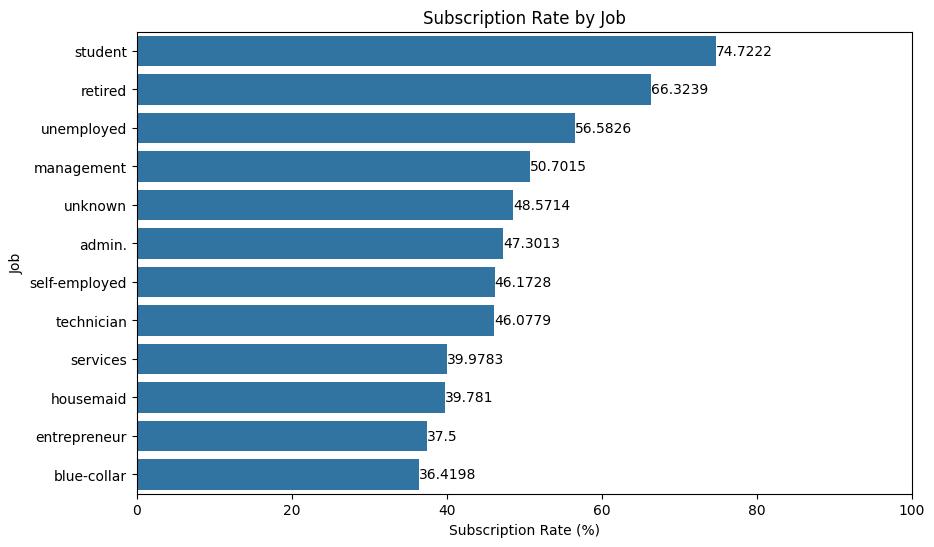

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=job_rate.reset_index(), x="yes", y="job")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.xlim(0,100)
plt.show()

Students had the highest subscription rate at 74.7%, followed by retired and unemployed customers. These groups were above the overall campaign subscription rate of 47.4%. Blue-collar customers had the lowest rate at 36.4%.

###**3.2 — Subscription Rate by Age**

In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0,30,40,50,60,100],
    labels=["Under 30","30-39","40-49","50-59","60+"]
)

In [ ]:
df["age_group"].value_counts().sort_index()

,count
age_group,
Under 30,2007
30-39,4188
40-49,2496
50-59,1860
60+,611


In [ ]:
pd.crosstab(df["age_group"], df["deposit"])

deposit,no,yes
age_group,,
Under 30,862,1145
30-39,2376,1812
40-49,1477,1019
50-59,1049,811
60+,109,502


In [ ]:
age_rate = pd.crosstab(
    df["age_group"],
    df["deposit"],
    normalize="index"
) * 100
display(age_rate)
print("\n\n Sorted subscription rate")
age_count = df["age_group"].value_counts().sort_index()
age_analysis = pd.DataFrame({
    "Customers": age_count,
    "Subscription Rate (%)": age_rate["yes"]
})
age_analysis

deposit,no,yes
age_group,,
Under 30,42.949676,57.050324
30-39,56.733524,43.266476
40-49,59.174679,40.825321
50-59,56.397849,43.602151
60+,17.839607,82.160393




 Sorted subscription rate


,Customers,Subscription Rate (%)
age_group,,
Under 30,2007,57.050324
30-39,4188,43.266476
40-49,2496,40.825321
50-59,1860,43.602151
60+,611,82.160393


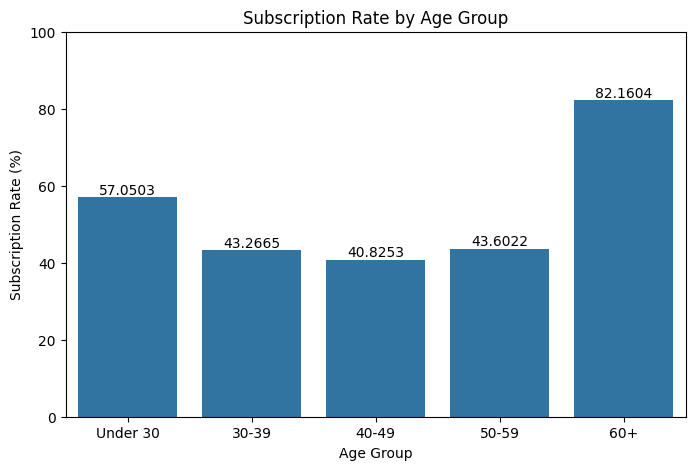

In [ ]:
plt.figure(figsize=(8,5))
ax=sns.barplot(
    data=age_rate.reset_index(),
    x="age_group",
    y="yes"
)
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers aged 60+ had the highest subscription rate at 82.2%, while the 40–49 group had the lowest at 40.8%. Under 30 and 60+ were the only age groups above the overall campaign subscription rate of 47.4%. The 30–39 group was the largest customer segment with 4,188 customers.

###**3.3 — Subscription Rate by Marital Status**

deposit,no,yes
marital,,
divorced,671,622
married,3596,2755
single,1606,1912


deposit,no,yes
marital,,
single,45.650938,54.349062
divorced,51.894818,48.105182
married,56.621005,43.378995


,count
marital,
married,6351
single,3518
divorced,1293


,Customers,Subscription Rate (%)
marital,,
divorced,1293,48.105182
married,6351,43.378995
single,3518,54.349062


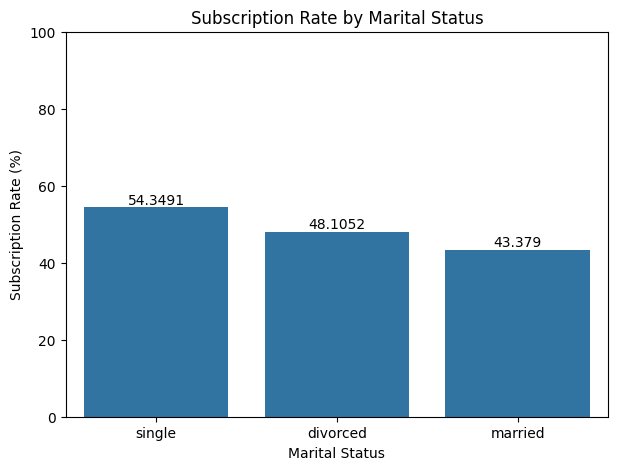

In [ ]:
# Subscription counts
marital_deposit = pd.crosstab(df["marital"], df["deposit"])
display(marital_deposit)

print("\n")

# Subscription rate
marital_rate = pd.crosstab(df["marital"], df["deposit"], normalize="index") * 100
marital_rate = marital_rate.sort_values("yes", ascending=False)
display(marital_rate)

print("\n")

# Customer count
marital_count = df["marital"].value_counts()
display(marital_count)

print("\n")

# Combined analysis
marital_analysis = pd.DataFrame({
    "Customers": marital_count,
    "Subscription Rate (%)": marital_rate["yes"]
})
display(marital_analysis)

# Subscription rate visualization
plt.figure(figsize=(7,5))
ax=sns.barplot(data=marital_rate.reset_index(), x="marital", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Single customers had the highest subscription rate (54.35%), while married customers had the lowest (43.38%). Single and divorced customers were above the overall 47.4% rate, while married customers formed the largest segment with 6,351 customers

###**3.4 — Subscription Rate by Education**

deposit,no,yes
education,,
primary,909,591
secondary,3026,2450
tertiary,1693,1996
unknown,245,252


deposit,no,yes
education,,
tertiary,45.893196,54.106804
unknown,49.295775,50.704225
secondary,55.259313,44.740687
primary,60.600000,39.400000


,count
education,
secondary,5476
tertiary,3689
primary,1500
unknown,497


,Customers,Subscription Rate (%)
education,,
primary,1500,39.400000
secondary,5476,44.740687
tertiary,3689,54.106804
unknown,497,50.704225


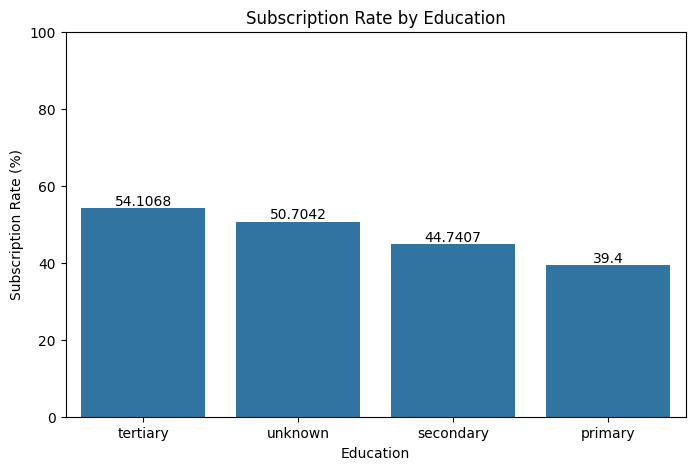

In [ ]:
# Subscription counts
education_deposit = pd.crosstab(df["education"], df["deposit"])
display(education_deposit)

print("\n")

# Subscription rate
education_rate = pd.crosstab(df["education"], df["deposit"], normalize="index") * 100
education_rate = education_rate.sort_values("yes", ascending=False)
display(education_rate)

print("\n")

# Customer count
education_count = df["education"].value_counts()
display(education_count)

print("\n")

# Combined analysis
education_analysis = pd.DataFrame({
    "Customers": education_count,
    "Subscription Rate (%)": education_rate["yes"]
})
display(education_analysis)

# Visualization
plt.figure(figsize=(8,5))
ax=sns.barplot(data=education_rate.reset_index(), x="education", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Tertiary-educated customers had the highest subscription rate at 54.1%, while primary-educated customers had the lowest at 39.4%. Tertiary and unknown groups were above the overall 47.4% rate, while secondary and primary were below it.

###**3.5 — Subscription Rate by Housing Loan**

deposit,no,yes
housing,,
no,2527,3354
yes,3346,1935


deposit,no,yes
housing,,
no,42.968883,57.031117
yes,63.359212,36.640788


,count
housing,
no,5881
yes,5281


,Customers,Subscription Rate (%)
housing,,
no,5881,57.031117
yes,5281,36.640788


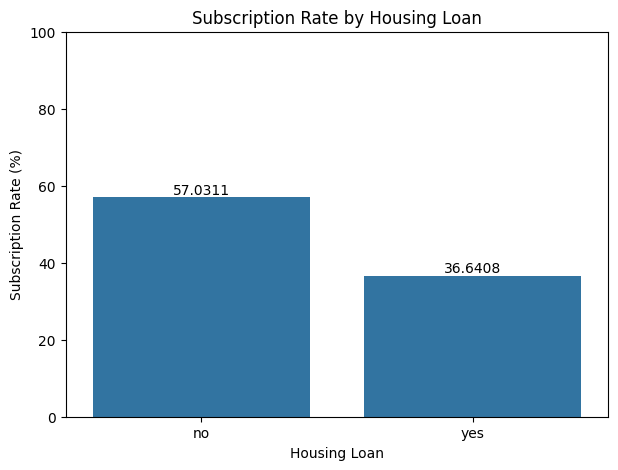

In [ ]:
# Subscription counts
housing_deposit = pd.crosstab(df["housing"], df["deposit"])
display(housing_deposit)

print("\n")

# Subscription rate
housing_rate = pd.crosstab(df["housing"], df["deposit"], normalize="index") * 100
housing_rate = housing_rate.sort_values("yes", ascending=False)
display(housing_rate)

print("\n")

# Customer count
housing_count = df["housing"].value_counts()
display(housing_count)

print("\n")

# Combined analysis
housing_analysis = pd.DataFrame({
    "Customers": housing_count,
    "Subscription Rate (%)": housing_rate["yes"]
})
display(housing_analysis)

# Visualization
plt.figure(figsize=(7,5))
ax=sns.barplot(data=housing_rate.reset_index(), x="housing", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Housing Loan")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers without a housing loan had a much higher subscription rate at 57.0%, compared with 36.6% for customers with a housing loan. The no-housing-loan group was also slightly larger, with 5,881 customers.

###**3.6 — Subscription Rate by Personal Loan**

deposit,no,yes
loan,,
no,4897,4805
yes,976,484


deposit,no,yes
loan,,
no,50.474129,49.525871
yes,66.849315,33.150685


,count
loan,
no,9702
yes,1460


,Customers,Subscription Rate (%)
loan,,
no,9702,49.525871
yes,1460,33.150685


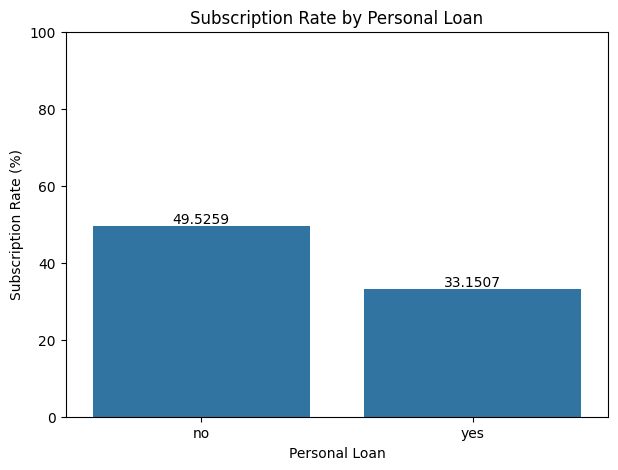

In [ ]:
# Subscription counts
loan_deposit = pd.crosstab(df["loan"], df["deposit"])
display(loan_deposit)

print("\n")

# Subscription rate
loan_rate = pd.crosstab(df["loan"], df["deposit"], normalize="index") * 100
loan_rate = loan_rate.sort_values("yes", ascending=False)
display(loan_rate)

print("\n")

# Customer count
loan_count = df["loan"].value_counts()
display(loan_count)

print("\n")

# Combined analysis
loan_analysis = pd.DataFrame({
    "Customers": loan_count,
    "Subscription Rate (%)": loan_rate["yes"]
})
display(loan_analysis)

# Visualization
plt.figure(figsize=(7,5))
ax=sns.barplot(data=loan_rate.reset_index(), x="loan", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Personal Loan")
plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers without a personal loan had a higher subscription rate at 49.5%, compared with 33.2% for customers with a personal loan. The no-loan group was much larger, with 9,702 customers.

###**3.7 — Subscription Rate by Credit Default**

deposit,no,yes
default,,
no,5757,5237
yes,116,52


deposit,no,yes
default,,
no,52.364926,47.635074
yes,69.047619,30.952381


,count
default,
no,10994
yes,168


,Customers,Subscription Rate (%)
default,,
no,10994,47.635074
yes,168,30.952381


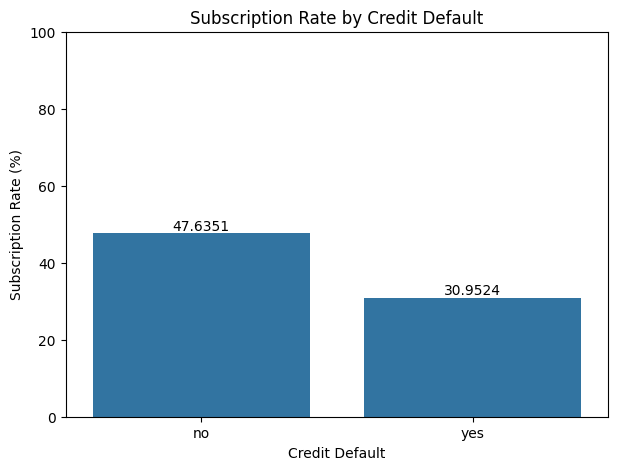

In [ ]:
# Subscription counts
default_deposit = pd.crosstab(df["default"], df["deposit"])
display(default_deposit)

print("\n")

# Subscription rate
default_rate = pd.crosstab(df["default"], df["deposit"], normalize="index") * 100
default_rate = default_rate.sort_values("yes", ascending=False)
display(default_rate)

print("\n")

# Customer count
default_count = df["default"].value_counts()
display(default_count)

print("\n")

# Combined analysis
default_analysis = pd.DataFrame({
    "Customers": default_count,
    "Subscription Rate (%)": default_rate["yes"]
})
display(default_analysis)

# Visualization
plt.figure(figsize=(7,5))
ax=sns.barplot(data=default_rate.reset_index(), x="default", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Credit Default")
plt.xlabel("Credit Default")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers without a credit default had a 47.6% subscription rate, compared with 31.0% for customers with a default. However, the default group was very small, with only 168 customers, so this difference should be interpreted cautiously.

## Phase 4 — Previous Marketing History

###**4.1 — Previous Campaign Outcome**

deposit,no,yes
poutcome,,
failure,610,618
other,230,307
success,93,978
unknown,4940,3386


deposit,no,yes
poutcome,,
success,8.683473,91.316527
other,42.830540,57.169460
failure,49.674267,50.325733
unknown,59.332212,40.667788


,count
poutcome,
unknown,8326
failure,1228
success,1071
other,537


,Customers,Subscription Rate (%)
poutcome,,
failure,1228,50.325733
other,537,57.169460
success,1071,91.316527
unknown,8326,40.667788


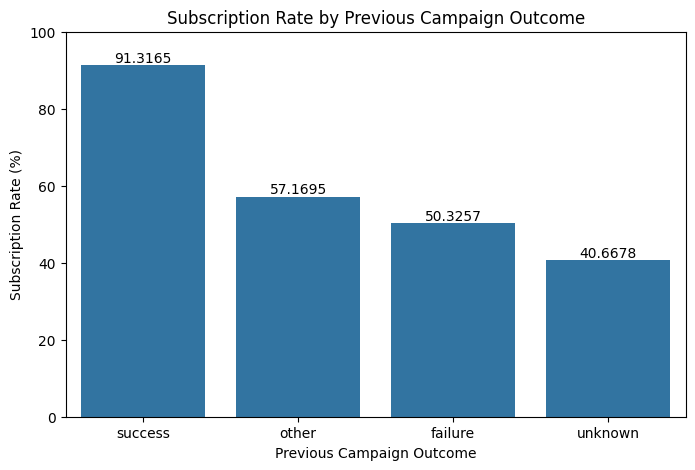

In [ ]:
# Previous campaign outcome
poutcome_deposit = pd.crosstab(df["poutcome"], df["deposit"])
display(poutcome_deposit)

print("\n")

# Subscription rate
poutcome_rate = pd.crosstab(df["poutcome"], df["deposit"], normalize="index") * 100
poutcome_rate = poutcome_rate.sort_values("yes", ascending=False)
display(poutcome_rate)

print("\n")

# Customer count
poutcome_count = df["poutcome"].value_counts()
display(poutcome_count)

print("\n")

# Combined analysis
poutcome_analysis = pd.DataFrame({
    "Customers": poutcome_count,
    "Subscription Rate (%)": poutcome_rate["yes"]
})
display(poutcome_analysis)

# Visualization
plt.figure(figsize=(8,5))
ax=sns.barplot(data=poutcome_rate.reset_index(), x="poutcome", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers with a previous successful outcome had the highest subscription rate at 91.3%, while customers with an unknown previous outcome had the lowest at 40.7%. Customers with previous success were strongly associated with subscribing again in the current campaign.

###**4.2 — Previous Contact History**

deposit,no,yes
previous,,
0,4940,3384
1,304,583
2,237,456
3,141,294
4,73,171
5,44,121
6,34,83
7,23,54
8,21,39


deposit,no,yes
previous,,
30,0.000000,100.000000
29,0.000000,100.000000
22,0.000000,100.000000
26,0.000000,100.000000
55,0.000000,100.000000
58,0.000000,100.000000
21,0.000000,100.000000
10,13.333333,86.666667
14,16.666667,83.333333


,count
previous,
0,8324
1,887
2,693
3,435
4,244
5,165
6,117
7,77
8,60


,Customers,Subscription Rate (%)
previous,,
0,8324,40.653532
1,887,65.727170
2,693,65.800866
3,435,67.586207
4,244,70.081967
5,165,73.333333
6,117,70.940171
7,77,70.129870
8,60,65.000000


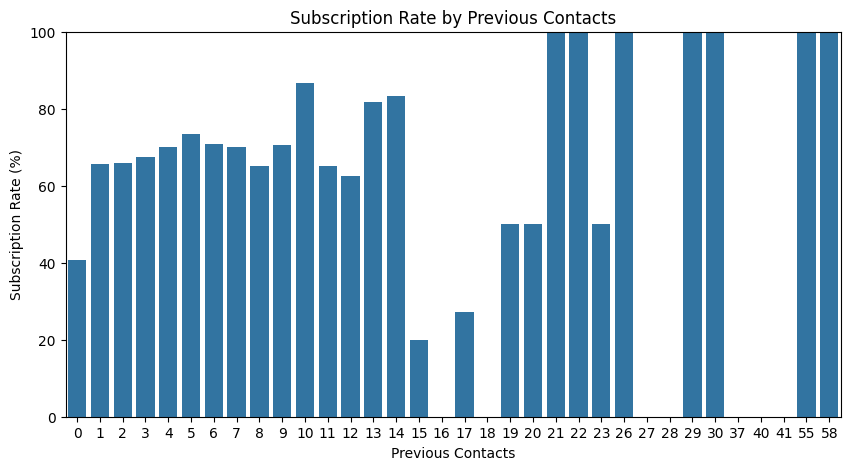

In [ ]:
# Subscription counts
previous_deposit = pd.crosstab(df["previous"], df["deposit"])
display(previous_deposit)

print("\n")

# Subscription rate
previous_rate = pd.crosstab(df["previous"], df["deposit"], normalize="index") * 100
previous_rate = previous_rate.sort_values("yes", ascending=False)
display(previous_rate)

print("\n")

# Customer count
previous_count = df["previous"].value_counts().sort_index()
display(previous_count)

print("\n")

# Combined analysis
previous_analysis = pd.DataFrame({
    "Customers": previous_count,
    "Subscription Rate (%)": previous_rate["yes"]
})
display(previous_analysis)

# Visualization
plt.figure(figsize=(10,5))
ax=sns.barplot(data=previous_analysis.reset_index(), x="previous", y="Subscription Rate (%)")
plt.title("Subscription Rate by Previous Contacts")
plt.xlabel("Previous Contacts")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Customers with previous contact history had substantially higher subscription rates than those with no previous contacts (40.7%). The rate generally increased through around 5 previous contacts, but higher contact counts had very small sample sizes and should not be overinterpreted

###**4.3 — Days Since Previous Contact**

deposit,no,yes
pdays_group,,
Never contacted,4940,3384
0-30 days,28,28
31-90 days,50,223
91-180 days,270,680
181+ days,585,974


deposit,no,yes
pdays_group,,
31-90 days,18.315018,81.684982
91-180 days,28.421053,71.578947
181+ days,37.524054,62.475946
0-30 days,50.000000,50.000000
Never contacted,59.346468,40.653532


,count
pdays_group,
Never contacted,8324
0-30 days,56
31-90 days,273
91-180 days,950
181+ days,1559


,Customers,Subscription Rate (%)
pdays_group,,
Never contacted,8324,40.653532
0-30 days,56,50.000000
31-90 days,273,81.684982
91-180 days,950,71.578947
181+ days,1559,62.475946


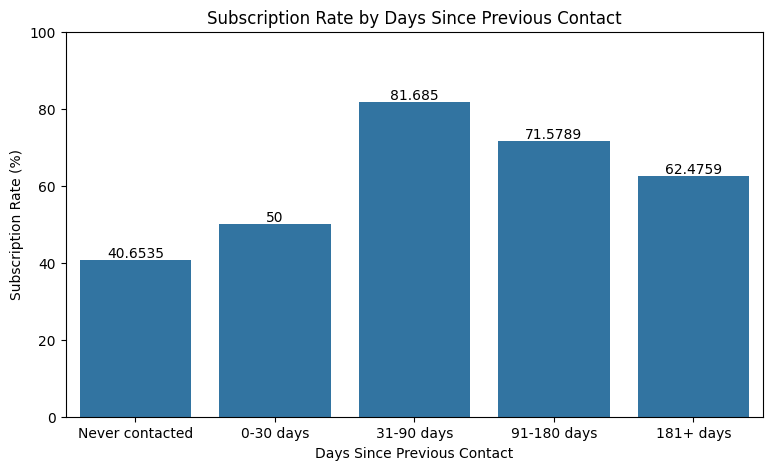

In [ ]:
# Create pdays groups
df["pdays_group"] = pd.cut(
    df["pdays"],
    bins=[-2,0,30,90,180,float("inf")],
    labels=["Never contacted","0-30 days","31-90 days","91-180 days","181+ days"]
)

# Subscription counts
pdays_deposit = pd.crosstab(df["pdays_group"], df["deposit"])
display(pdays_deposit)

print("\n")

# Subscription rate
pdays_rate = pd.crosstab(df["pdays_group"], df["deposit"], normalize="index") * 100
pdays_rate = pdays_rate.sort_values("yes", ascending=False)
display(pdays_rate)

print("\n")

# Customer count
pdays_count = df["pdays_group"].value_counts().sort_index()
display(pdays_count)

print("\n")

# Combined analysis
pdays_analysis = pd.DataFrame({
    "Customers": pdays_count,
    "Subscription Rate (%)": pdays_rate["yes"]
})
display(pdays_analysis)

# Visualization
plt.figure(figsize=(9,5))
ax=sns.barplot(data=pdays_rate.reset_index(), x="pdays_group", y="yes")
for cont in ax.containers:
    ax.bar_label(cont)
plt.title("Subscription Rate by Days Since Previous Contact")
plt.xlabel("Days Since Previous Contact")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Previously contacted customers generally had higher subscription rates than those never contacted. The 31–90 day group had the highest rate at 81.7%, while never-contacted customers had the lowest at 40.7%.

## Phase 5 — Current Campaign Behaviour

### **5.1 — Number of Contacts**

deposit,no,yes
campaign,,
1,2237,2561
2,1627,1401
3,703,618
4,454,317
5,239,139
6,173,92
7,92,47
8,96,32
9,51,21


deposit,no,yes
campaign,,
1,46.623593,53.376407
29,50.000000,50.000000
32,50.000000,50.000000
3,53.217260,46.782740
2,53.731836,46.268164
17,57.142857,42.857143
4,58.884565,41.115435
11,60.000000,40.000000
5,63.227513,36.772487


,count
campaign,
1,4798
2,3028
3,1321
4,771
5,378
6,265
7,139
8,128
9,72


,Customers,Subscription Rate (%)
campaign,,
1,4798,53.376407
2,3028,46.268164
3,1321,46.782740
4,771,41.115435
5,378,36.772487
6,265,34.716981
7,139,33.812950
8,128,25.000000
9,72,29.166667


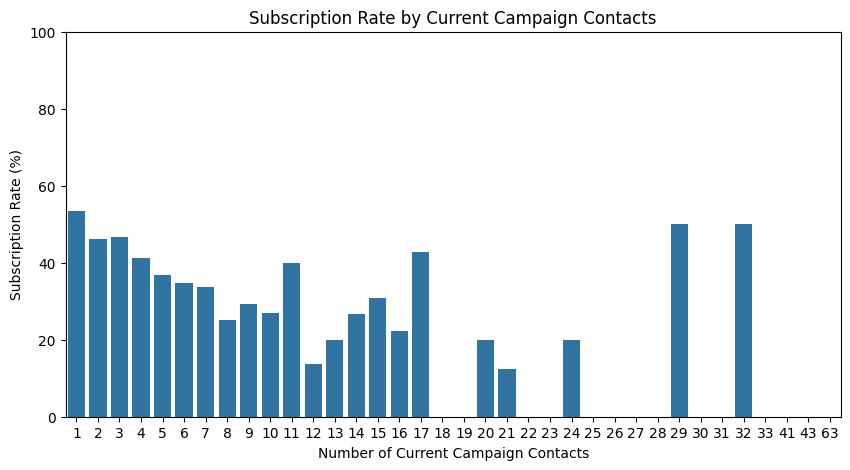

In [ ]:
# Subscription counts
campaign_deposit = pd.crosstab(df["campaign"], df["deposit"])
display(campaign_deposit)

print("\n")

# Subscription rate
campaign_rate = pd.crosstab(df["campaign"], df["deposit"], normalize="index") * 100
campaign_rate = campaign_rate.sort_values("yes", ascending=False)
display(campaign_rate)

print("\n")

# Customer count
campaign_count = df["campaign"].value_counts().sort_index()
display(campaign_count)

print("\n")

# Combined analysis
campaign_analysis = pd.DataFrame({
    "Customers": campaign_count,
    "Subscription Rate (%)": campaign_rate["yes"]
})
display(campaign_analysis)

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(data=campaign_analysis.reset_index(), x="campaign", y="Subscription Rate (%)")
plt.title("Subscription Rate by Current Campaign Contacts")
plt.xlabel("Number of Current Campaign Contacts")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

### **5.2 — Call Duration**

,count,mean,median,min,max
deposit,,,,,
no,5873,223.130257,163.0,2,3284
yes,5289,537.294574,426.0,8,3881


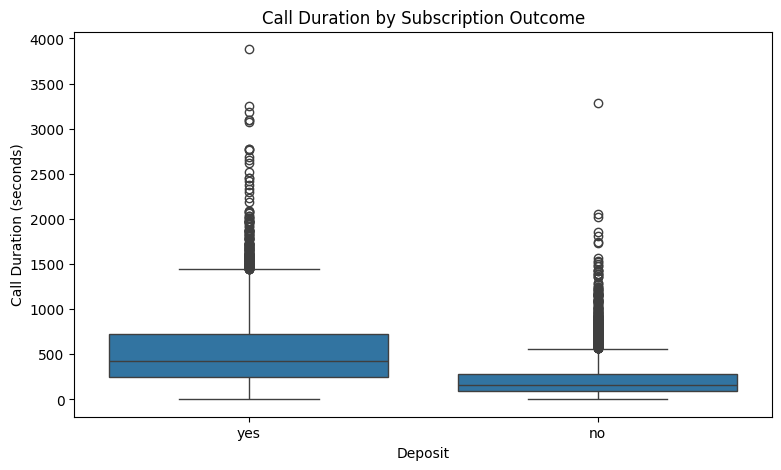

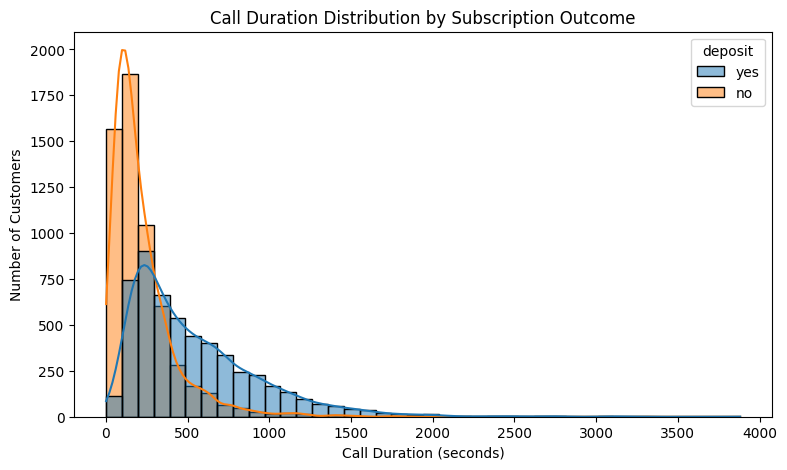

In [ ]:
# Call duration summary
duration_summary = df.groupby("deposit")["duration"].agg(["count","mean","median","min","max"])
display(duration_summary)

print("\n")

# Call duration distribution
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="deposit", y="duration")
plt.title("Call Duration by Subscription Outcome")
plt.xlabel("Deposit")
plt.ylabel("Call Duration (seconds)")
plt.show()

print("\n")

# Call duration distribution by outcome
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="duration", hue="deposit", bins=40, kde=True)
plt.title("Call Duration Distribution by Subscription Outcome")
plt.xlabel("Call Duration (seconds)")
plt.ylabel("Number of Customers")
plt.show()

### **5.3 — Contact Method**

deposit,no,yes
contact,,
cellular,3673,4369
telephone,384,390
unknown,1816,530


deposit,no,yes
contact,,
cellular,45.672718,54.327282
telephone,49.612403,50.387597
unknown,77.408355,22.591645


,count
contact,
cellular,8042
unknown,2346
telephone,774


,Customers,Subscription Rate (%)
contact,,
cellular,8042,54.327282
telephone,774,50.387597
unknown,2346,22.591645


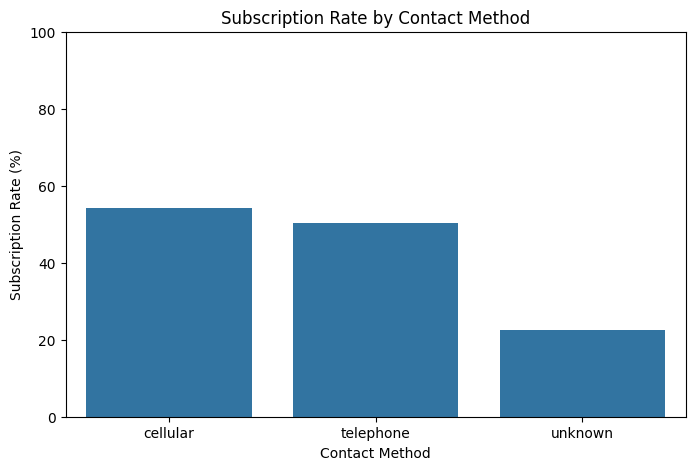

In [ ]:
# Subscription counts
contact_deposit = pd.crosstab(df["contact"], df["deposit"])
display(contact_deposit)

print("\n")

# Subscription rate
contact_rate = pd.crosstab(df["contact"], df["deposit"], normalize="index") * 100
contact_rate = contact_rate.sort_values("yes", ascending=False)
display(contact_rate)

print("\n")

# Customer count
contact_count = df["contact"].value_counts()
display(contact_count)

print("\n")

# Combined analysis
contact_analysis = pd.DataFrame({
    "Customers": contact_count,
    "Subscription Rate (%)": contact_rate["yes"]
})
display(contact_analysis)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(data=contact_rate.reset_index(), x="contact", y="yes")
plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

Cellular had the highest subscription rate at 54.3% and the largest customer volume with 8,042 customers. Telephone also performed above the overall 47.4% rate at 50.4%, but had a smaller volume of 774 customers. Unknown had the lowest subscription rate at 22.6%, so it may be worth investigating why the contact method is unknown

### **5.4 — Contact Month**

deposit,no,yes
month,,
jan,202,142
feb,335,441
mar,28,248
apr,346,577
may,1899,925
jun,676,546
jul,887,627
aug,831,688
sep,50,269


deposit,no,yes
month,,
jan,58.720930,41.279070
feb,43.170103,56.829897
mar,10.144928,89.855072
apr,37.486457,62.513543
may,67.245042,32.754958
jun,55.319149,44.680851
jul,58.586526,41.413474
aug,54.707044,45.292956
sep,15.673981,84.326019


,count
month,
jan,344
feb,776
mar,276
apr,923
may,2824
jun,1222
jul,1514
aug,1519
sep,319


,Customers,Subscription Rate (%)
month,,
jan,344,41.279070
feb,776,56.829897
mar,276,89.855072
apr,923,62.513543
may,2824,32.754958
jun,1222,44.680851
jul,1514,41.413474
aug,1519,45.292956
sep,319,84.326019


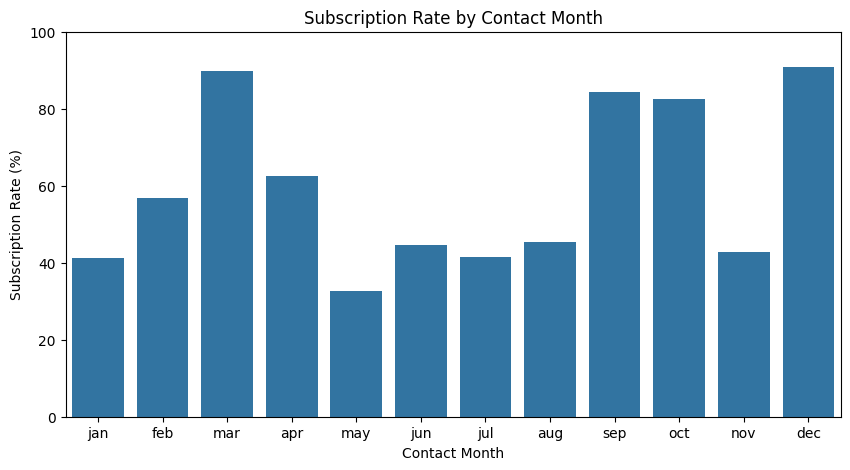

In [ ]:
# Set month order
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

# Subscription counts
month_deposit = pd.crosstab(df["month"], df["deposit"])
display(month_deposit)

print("\n")

# Subscription rate
month_rate = pd.crosstab(df["month"], df["deposit"], normalize="index") * 100
display(month_rate)

print("\n")

# Customer count
month_count = df["month"].value_counts().sort_index()
display(month_count)

print("\n")

# Combined analysis
month_analysis = pd.DataFrame({
    "Customers": month_count,
    "Subscription Rate (%)": month_rate["yes"]
})
display(month_analysis)

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(data=month_rate.reset_index(), x="month", y="yes")
plt.title("Subscription Rate by Contact Month")
plt.xlabel("Contact Month")
plt.ylabel("Subscription Rate (%)")
plt.ylim(0,100)
plt.show()

December had the highest subscription rate at 90.9%, followed by March at 89.9%, while May had the lowest at 32.8%. May was also the largest customer group with 2,824 customers. Overall, May to August showed weaker subscription performance, whereas March, September, October, and December showed much stronger rates. However, some of these high-performing months had relatively small customer volumes, so the pattern should be investigated further before drawing conclusions.

## Phase 6 — Numeric Relationships

### **6.1 — Numeric Variables by Subscription Outcome**

In [ ]:
numeric_cols = ["age", "balance", "duration", "campaign", "previous", "pdays"]

numeric_summary = df.groupby("deposit")[numeric_cols].agg(["mean", "median"])

display(numeric_summary)

age             balance           duration         campaign  \
              mean median         mean median        mean median      mean   
deposit                                                                      
no       40.837391   39.0  1280.227141  414.0  223.130257  163.0  2.839264   
yes      41.670070   38.0  1804.267915  733.0  537.294574  426.0  2.141047   

                previous             pdays         
        median      mean median       mean median  
deposit                                            
no         2.0  0.528350    0.0  35.685340   -1.0  
yes        2.0  1.170354    0.0  68.702968   -1.0

Customers who subscribed had a much higher average and median balance (₹1,804 / ₹733) compared with non-subscribers (₹1,280 / ₹414). Call duration showed the strongest difference, with subscribers having a median duration of 426 seconds compared with 163 seconds for non-subscribers. Subscribers also had fewer current-campaign contacts on average (2.14 vs 2.84) and more previous contacts (1.17 vs 0.53). Age was very similar between both groups, suggesting it has a weaker relationship with subscription compared with factors such as balance, call duration, and contact history.

### **6.2 — Correlation Analysis**

,age,balance,duration,campaign,previous,pdays
age,1.000000,0.112300,0.000189,-0.005278,0.020169,0.002774
balance,0.112300,1.000000,0.022436,-0.013894,0.030805,0.017411
duration,0.000189,0.022436,1.000000,-0.041557,-0.026716,-0.027392
campaign,-0.005278,-0.013894,-0.041557,1.000000,-0.049699,-0.102726
previous,0.020169,0.030805,-0.026716,-0.049699,1.000000,0.507272
pdays,0.002774,0.017411,-0.027392,-0.102726,0.507272,1.000000


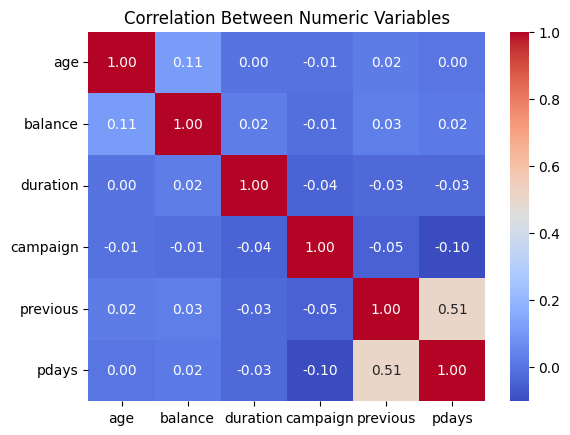

In [ ]:
corr_matrix = df[numeric_cols].corr()

display(corr_matrix)

print("\n")

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numeric Variables")
plt.show()

Most numeric variables show very weak correlations with each other, with values close to 0. The strongest relationship is between previous and pdays at 0.51, indicating a moderate positive relationship between the number of previous contacts and days since the previous contact. Other relationships are weak, including campaign and pdays (-0.10) and age and balance (0.11). Overall, there are no strong linear relationships among most numeric variables.

## Phase 7 — Deeper Customer Analysis

### **7.1 — Age Group + Job**

In [ ]:
segment = df.groupby(["age_group", "job"], observed=False).agg(
    Customers=("deposit", "size"),
    Subscriptions=("deposit", lambda x: (x == "yes").sum()),
    Subscription_Rate=("deposit", lambda x: (x == "yes").mean() * 100)
).reset_index()

segment = segment[segment["Customers"] >= 100]
segment = segment.sort_values("Subscription_Rate", ascending=False)

display(segment)

,age_group,job,Customers,Subscriptions,Subscription_Rate
53,60+,retired,461,375.0,81.344902
8,Under 30,student,305,235.0,77.049180
4,Under 30,management,386,234.0,60.621762
22,30-39,unemployed,126,71.0,56.349206
9,Under 30,technician,317,169.0,53.312303
0,Under 30,admin.,269,143.0,53.159851
45,50-59,technician,253,132.0,52.173913
16,30-39,management,1123,551.0,49.065004
36,50-59,admin.,196,96.0,48.979592
28,40-49,management,580,280.0,48.275862


The 60+ retired segment had the highest subscription rate at 81.3%, followed by Under 30 students at 77.0%. Under 30 management customers also performed well at 60.6%. On the lower end, 50–59 blue-collar customers had the lowest rate at 33.3%, followed by 30–39 and 40–49 blue-collar customers at around 34.2% and 34.3%. This suggests that subscription performance varies considerably across specific age–job segments, with older retired and younger student segments showing stronger engagement, while blue-collar segments consistently performed weaker.

### **7.2 — Education + Housing Loan**

In [ ]:
segment_2 = df.groupby(["education", "housing"]).agg(
    Customers=("deposit", "size"),
    Subscriptions=("deposit", lambda x: (x == "yes").sum()),
    Subscription_Rate=("deposit", lambda x: (x == "yes").mean() * 100)
).reset_index()

segment_2 = segment_2[segment_2["Customers"] >= 100]
segment_2 = segment_2.sort_values("Subscription_Rate", ascending=False)

display(segment_2)

,education,housing,Customers,Subscriptions,Subscription_Rate
4,tertiary,no,2245,1382,61.559020
6,unknown,no,323,193,59.752322
2,secondary,no,2555,1413,55.303327
0,primary,no,758,366,48.284960
5,tertiary,yes,1444,614,42.520776
3,secondary,yes,2921,1037,35.501541
7,unknown,yes,174,59,33.908046
1,primary,yes,742,225,30.323450


Tertiary-educated customers without a housing loan had the highest subscription rate at 61.6%, followed by customers with unknown education and no housing loan at 59.8%. Across every education level, customers without a housing loan had higher subscription rates than those with a housing loan. Primary-educated customers with a housing loan had the lowest rate at 30.3%. Overall, the combination of education level and housing-loan status shows a clear difference in campaign response.

### **7.3 — Marital Status + Personal Loan**

In [ ]:
segment_3 = df.groupby(["marital", "loan"]).agg(
    Customers=("deposit", "size"),
    Subscriptions=("deposit", lambda x: (x == "yes").sum()),
    Subscription_Rate=("deposit", lambda x: (x == "yes").mean() * 100)
).reset_index()

segment_3 = segment_3[segment_3["Customers"] >= 100]
segment_3 = segment_3.sort_values("Subscription_Rate", ascending=False)

display(segment_3)

,marital,loan,Customers,Subscriptions,Subscription_Rate
4,single,no,3172,1765,55.643127
0,divorced,no,1092,555,50.824176
2,married,no,5438,2485,45.696947
5,single,yes,346,147,42.485549
1,divorced,yes,201,67,33.333333
3,married,yes,913,270,29.572837


Single customers without a personal loan had the highest subscription rate at 55.6%, followed by divorced customers without a personal loan at 50.8%. Across all three marital-status groups, customers without a personal loan consistently had higher subscription rates than those with a personal loan. Married customers with a personal loan had the lowest rate at 29.6%. Overall, personal-loan status shows a clear difference in campaign response across marital-status segments.

### **7.4 — Contact Method + Housing Loan**

In [ ]:
segment_4 = df.groupby(["contact", "housing"]).agg(
    Customers=("deposit", "size"),
    Subscriptions=("deposit", lambda x: (x == "yes").sum()),
    Subscription_Rate=("deposit", lambda x: (x == "yes").mean() * 100)
).reset_index()

segment_4 = segment_4[segment_4["Customers"] >= 100]
segment_4 = segment_4.sort_values("Subscription_Rate", ascending=False)

display(segment_4)

,contact,housing,Customers,Subscriptions,Subscription_Rate
0,cellular,no,4691,2883,61.458111
2,telephone,no,533,313,58.724203
1,cellular,yes,3351,1486,44.344972
3,telephone,yes,241,77,31.950207
4,unknown,no,657,158,24.048706
5,unknown,yes,1689,372,22.024867


Customers without a housing loan consistently had higher subscription rates. Cellular + no housing loan performed best at 61.5%, while unknown contact groups had the lowest rates at around 22–24%. Overall, housing-loan status showed a stronger pattern than contact method.

## Phase 8 — Business Insights

### 8.1 — Key Customer Findings

- Students and 60+ retired customers showed the highest subscription rates.
- Customers without housing or personal loans generally subscribed at higher rates.
- Tertiary-educated and single customers showed stronger subscription rates than their lower-performing groups.
- Blue-collar customer segments generally showed weaker subscription performance.**bold text**

### 8.2 — Marketing History Findings
- Customers with a previous successful campaign outcome had a very high subscription rate of 91.3%.
- Customers with previous contact history generally subscribed at higher rates than customers who had never been contacted.
- Customers contacted 31–90 days earlier had the highest subscription rate among the pdays groups at 81.7%.
- The unknown previous-outcome group was the largest group (8,326 customers) but had a lower subscription rate of 40.7%.

### 8.3 — Current Campaign Findings
- Customers receiving fewer current-campaign contacts generally showed better subscription rates.
- Subscribed customers had a much higher median call duration (426 sec) than non-subscribers (163 sec).
- Cellular contact had the highest subscription rate among the known contact methods at 54.3%.
- May to August showed weaker campaign performance, with May recording the lowest rate at 32.8%.

### 8.4 — High-Value Customer Segments
- 60+ retired: 81.3% subscription rate.
- Under 30 students: 77.0%.
- Under 30 management: 60.6%.
- Blue-collar segments across multiple age groups were around 33–34%.
- The 30–39 management segment generated the highest number of subscriptions (551) because of its large customer base.

### 8.5 — Findings → Evidence → Marketing Strategy
| Finding | Evidence | Marketing Strategy |
|---|---|---|
| Previous success strongly relates to subscription | 91.3% subscription rate | Prioritize customers with successful previous outcomes |
| Longer calls are associated with higher conversion | Median 426 sec vs 163 sec | Focus on quality conversations rather than simply increasing call volume |
| Repeated calling shows weaker performance | 1 contact: 53.4%; rates generally decline with more contacts | Avoid excessive repeated calls and improve targeting |
| Some customer segments respond better | 60+ retired: 81.3%; students: 77.0% | Prioritize high-performing customer segments |
| May–August underperforms | May: 32.8%; Jun–Aug: ~41–45% | Investigate campaign timing, messaging, or targeting during this period |
| Customers without loans respond better | Housing loan: 36.6% vs no loan: 57.0% | Consider differentiated messaging for customers with loans |
| Unknown contact/history groups perform poorly | Unknown contact: 22.6%; unknown previous outcome: 40.7% | Investigate data quality and improve customer-history tracking |

### 8.6 — Final Business Conclusion
The campaign achieved an overall subscription rate of 47.4%, but performance varied substantially across customer characteristics, previous marketing history, and campaign behaviour. Previous campaign success, customer segment, call duration, and loan status showed notable associations with subscription. The bank could improve campaign efficiency by prioritizing high-potential customers, reducing excessive repeated contacts, focusing on quality conversations, and investigating weaker periods such as May–August.